In [ ]:
import json

error_log="/home/rtml/shounak_research/bevfusion/match_anything_inference/MatchAnything/out_matchanything_all_evaluate/distance_errors.json"

#Load json and get average distance error
with open(error_log, 'r') as f:
    data = json.load(f)
total_distance_error = 0.0
count = 0
for item in data:
    if 'distance_m' in item:
        total_distance_error += item['distance_m']
        count += 1

average_distance_error = total_distance_error / count if count > 0 else 0.0
print(f"Average Distance Error: {average_distance_error} meters")



Average Distance Error: 28.643826806648576 meters


Average Distance Error (calculated): 28.643826806648576 meters


In [20]:
#Coarse error to fine error mapping
coarse_to_fine_mapping = {}
for item in data:
    try:
        id=item['id']
        json_file="../../scripts_2026_fine/viz_dino_best_3x3crop/"+id+"_metas_annotation.json"
        with open(json_file, 'r') as f:
            json_data = json.load(f)
        #L2 error json_data['top_pred_rowcol']-json_data['gt_rowcol']
        coarse_error = ((json_data['top_pred_rowcol'][0] - json_data['gt_rowcol'][0]) ** 2 + (json_data['top_pred_rowcol'][1] - json_data['gt_rowcol'][1]) ** 2) ** 0.5
        coarse_to_fine_mapping[id] = [coarse_error, item['distance_m']]
    except:
        print(f"Error processing {id}")

In [27]:
#Find average fine error for all unique coarse error values
unique_coarse_errors = set()
fine_errors_by_coarse = {}

for id, values in coarse_to_fine_mapping.items():
    coarse_error, fine_error = values
    unique_coarse_errors.add(coarse_error)
    if coarse_error not in fine_errors_by_coarse:
        fine_errors_by_coarse[coarse_error] = []
    fine_errors_by_coarse[coarse_error].append(fine_error)

# Calculate average fine error for each unique coarse error value
average_fine_errors = {}
for coarse_error in unique_coarse_errors:
    average_fine_errors[coarse_error] = sum(fine_errors_by_coarse[coarse_error]) / len(fine_errors_by_coarse[coarse_error])

#Print average fine errors for each coarse error
for coarse_error in sorted(average_fine_errors.keys())[:5]:
    print(f"Coarse Error: {coarse_error}, Average Fine Error: {average_fine_errors[coarse_error]/2} meters")

#Average error across the first 3 coarse error bins
sorted_coarse_errors = sorted(average_fine_errors.keys())
first_3_bins = sorted_coarse_errors[:3]
total_fine_error = 0.0
for coarse_error in first_3_bins:
    total_fine_error += average_fine_errors[coarse_error]   
average_fine_error_first_3_bins = total_fine_error / len(first_3_bins) if len(first_3_bins) > 0 else 0.0
print(f"Average Fine Error across first 3 coarse error bins: {average_fine_error_first_3_bins/2} meters")

#Print the counts of each coarse error bin
for coarse_error in sorted(unique_coarse_errors)[:3]:
    count = len(fine_errors_by_coarse[coarse_error])
    print(f"Coarse Error: {coarse_error}, Count: {count}")


#Print the remaining total count
total_count = len(coarse_to_fine_mapping)
counted = sum(len(fine_errors_by_coarse[coarse_error]) for coarse_error in sorted(unique_coarse_errors)[:3])
remaining_count = total_count - counted
print(f"Remaining Count: {remaining_count}")

Coarse Error: 0.0, Average Fine Error: 4.763824867166981 meters
Coarse Error: 1.0, Average Fine Error: 14.191062418994631 meters
Coarse Error: 1.4142135623730951, Average Fine Error: 33.29926905296618 meters
Coarse Error: 2.0, Average Fine Error: 88.99777077072271 meters
Coarse Error: 2.23606797749979, Average Fine Error: 100.83283763099526 meters
Average Fine Error across first 3 coarse error bins: 17.4180521130426 meters
Coarse Error: 0.0, Count: 3042
Coarse Error: 1.0, Count: 1812
Coarse Error: 1.4142135623730951, Count: 516
Remaining Count: 602


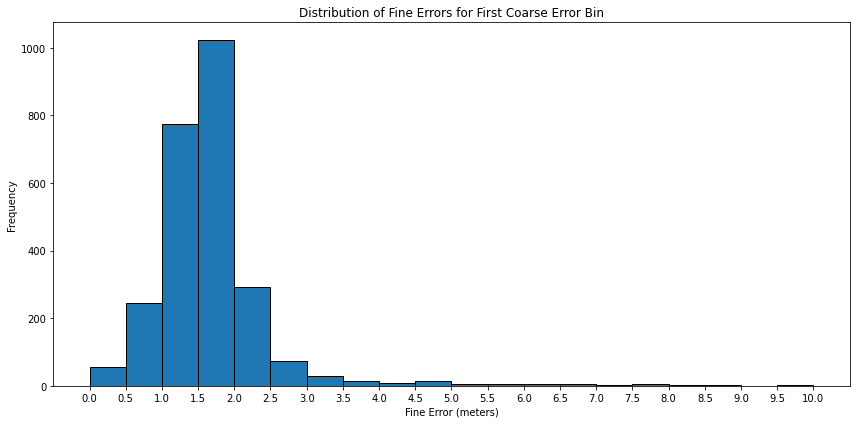

In [30]:
import matplotlib.pyplot as plt
import numpy as np  

first_coarse_error = sorted(unique_coarse_errors)[0]
coarse_errors_list = fine_errors_by_coarse[first_coarse_error]

plt.figure(figsize=(12, 6))  # <-- make figure larger (width, height in inches)

plt.hist(coarse_errors_list,
         bins=np.arange(0, 10.5, 0.5),
         edgecolor='black')

plt.xticks(np.arange(0, 10.5, 0.5))
plt.xlabel('Fine Error (meters)')
plt.ylabel('Frequency')
plt.title('Distribution of Fine Errors for First Coarse Error Bin')

plt.tight_layout()  # helps spacing for dense x-ticks
plt.show()
